In [1]:
import numpy as np
from astropy.table import Table, MaskedColumn
from astropy.time import Time

from matplotlib import pyplot as plt

In [2]:
t = Table.read('data/Feb2026.csv', format='ascii.csv')
t.remove_columns(['ObsID', 'OBJECT', 'TARGNAME', 'TOTCNTS', 'CCFRV_MPS', 'CCD1RV_MPS', 'CCD2RV_MPS', 'CCFERV_MPS', 'CCFBJD', 'CCFERV'])

In [3]:
# Separate out TOTCORR values to separate columns
TOTCORR_1 = MaskedColumn(data=np.zeros(len(t)), name='TOTCORR_1')
TOTCORR_2 = MaskedColumn(data=np.zeros(len(t)), name='TOTCORR_2')
TOTCORR_3 = MaskedColumn(data=np.zeros(len(t)), name='TOTCORR_3')
TOTCORR_4 = MaskedColumn(data=np.zeros(len(t)), name='TOTCORR_4')
TOTCORR_SUM = MaskedColumn(data=np.zeros(len(t)), name='TOTCORR_SUM')
for i,row in enumerate(t):
    masked = t['TOTCORR'].mask[i]
    if not masked:
        TOTCORR_1[i] = t['TOTCORR'][i].split()[0]
        TOTCORR_2[i] = t['TOTCORR'][i].split()[1]
        TOTCORR_3[i] = t['TOTCORR'][i].split()[2]
        TOTCORR_4[i] = t['TOTCORR'][i].split()[3]
        TOTCORR_SUM[i] = np.sum([float(v) for v in t['TOTCORR'][i].split()])
TOTCORR_1.mask = t['TOTCORR'].mask
TOTCORR_2.mask = t['TOTCORR'].mask
TOTCORR_3.mask = t['TOTCORR'].mask
TOTCORR_4.mask = t['TOTCORR'].mask
TOTCORR_SUM.mask = t['TOTCORR'].mask
t.add_columns([TOTCORR_1, TOTCORR_2, TOTCORR_3, TOTCORR_4, TOTCORR_SUM])
len(t)

13584

In [4]:
# Remove Data with MJD-OBS Before KPF was Installed
t = t[t['MJD-OBS'] > 59200]
len(t)

13547

In [5]:
# Remove Data with Gmag<=0
t = t[t['GAIAMAG'] > 0]
len(t)

12700

In [6]:
#because of missing labeling in OBs, this was a default value, so remove all stars with this value as the data is not usable.
t = t[(t['GAIAMAG'] < 9.2) | (t['GAIAMAG'] > 9.5)]
len(t)

12118

In [7]:
# Remove very short exposures (removes start state errors)
t = t[t['ELAPSED'] > 7]
len(t)

12058

In [8]:
t.write('data/Feb2026_anonymized.csv', overwrite=True)

# Examine Properties of Data Set

In [9]:
# KPFERA 1.0 is before SM1
SM1start = Time('2024-02-03')
SM1end = Time('2024-02-23')
# KPFERA 2.0 is between SM1 and SM2
SM2start = Time('2024-10-31')
SM2end = Time('2024-11-20')
# KPFERA 2.5/2.6 is between SM2 and SM3
SM3start = Time('2025-03-28')
SM3end = Time('2025-04-23')
# KPFERA 3.0 is between SM3 and SM4
SM4start = Time('2025-08-29')
SM4end = Time('2025-10-27')
# KPFERA 4.0 is after SM4

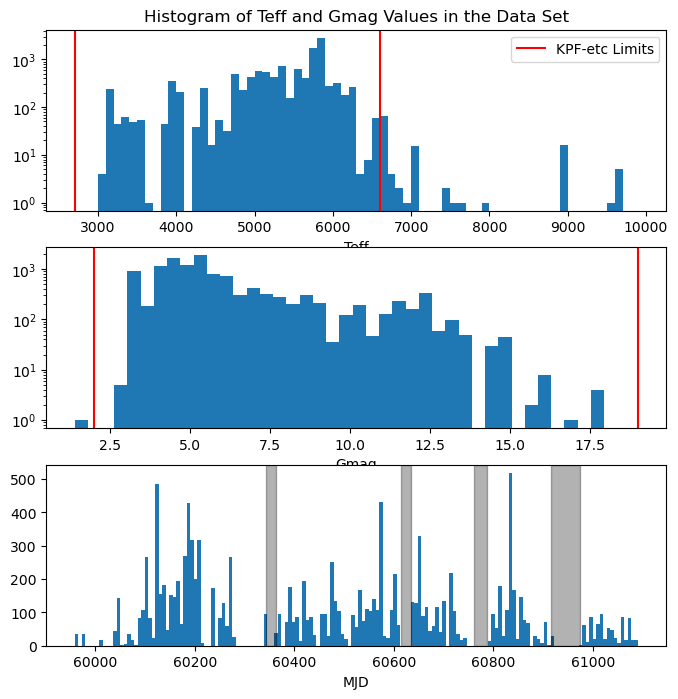

In [10]:
plt.figure(figsize=(8,8))

plt.subplot(3,1,1)
plt.title('Histogram of Teff and Gmag Values in the Data Set')
bins=np.arange(2700,10000,100)
plt.hist(t['TARGTEFF'], bins=bins, log=True)
plt.axvline(2700, color='r', label='KPF-etc Limits')
plt.axvline(6600, color='r')
plt.xlabel('Teff')
plt.legend(loc='best')

plt.subplot(3,1,2)
plt.hist(t['GAIAMAG'], bins=40, log=True)
plt.axvline(2, color='r', label='KPF-etc Limits')
plt.axvline(19, color='r')
plt.xlabel('Gmag')

plt.subplot(3,1,3)
nd = max(t['MJD-OBS'])-min(t['MJD-OBS'])
plt.hist(t['MJD-OBS'], bins=int(nd/7))
plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
plt.xlabel('MJD')

plt.show()

In [26]:
drpvs = set([str(v) for v in t['DRPTAGL2']])
print("DRPTAGL2   : N Files")
print("____________________")
total = 0
for v in sorted(drpvs):
    if v == '--':
        Nv = np.sum(np.array(t['DRPTAGL2'].mask, dtype=int))
    else:
        tv = t[t['DRPTAGL2'] == v]
        Nv = len(tv)
    total += Nv
    print(f"{v:11s}: {Nv}")
print(f"TOTAL = {total} ({len(t)})")

DRPTAGL2   : N Files
____________________
--         : 38
v2.10.3    : 3216
v2.11.1    : 23
v2.12.0rc1 : 4369
v2.5.3     : 35
v2.8.2     : 2030
v2.9.1     : 2347
TOTAL = 12058 (12058)
